In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog
from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    calculate_thresholds,
    discover_leaves,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    get_data,
    parse_tag,
    plot_flags,
    run_flag_loop,
    write_individual_flags,
)

In [2]:
from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.qaqc import calculate_distortion_flags, sign_flip_mask

# A. Define what data arrays exist to traverse

In [3]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [4]:
GCMS = ["CESM2-WACCM"]

# BRANCH = "full-regional-run-issue-534"
# ROOT_DIR = "s3://carbonplan-scratch/srm/output/qa/"
# STORE_SUBSET_BOUNDS = (-38.0, -19.0, 13.0, 36.0)
# STORE_SUBSET_ID = ArtifactCache._get_subset_id(STORE_SUBSET_BOUNDS)

BRANCH = "v0.13.0"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

In [5]:
[trees, tags, gcms_np, scenarios_np, variables_np, tags_np] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID
)

opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM
71 leaves across 1 GCMs


In [6]:
PLOT_FLAG_MAPS = True
BUCKET = "carbonplan-srm"
PREFIX = "scratch/output/qa-intermediate-flags"

## Set up cluster

In [12]:
import os

import coiled
from frisky import hijack

from srm.config import (
    ClusterConfig,
)

os.environ["FRISKY_SUMMARY"] = "off"

In [13]:
cfg = ClusterConfig(
    n_workers=20,
    worker_vm_types=["r8g.2xlarge"],  # 8 vCPU, 64 GB
    scheduler_vm_types=["r8g.2xlarge"],
    spot_policy="spot_with_fallback",
)

cluster = coiled.Cluster(
    name="srm-qaqc-flag-generation",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=250,
)

client = hijack(cluster.get_client())

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Source wheel built from /scratch/synced/src             │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from /scratch/synced                        │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

# B. Generate individual time-varying QA flags

## 1. global exceedances

In [16]:
run_flag_loop(
    tags=tags,
    trees=trees,
    bucket=BUCKET,
    prefix=PREFIX,
    flag_name="outside_global_plausible_range",
    compute_flag=lambda da, var: flag_global_exceedances(da=da, var=var),
    write_mode="w",
)

31
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmin_g6_1p5k_end_002
CESM2-WACCM_pr_g6_1p5k_end_002
CESM2-WACCM_rsds_g6_1p5k_end_002
CESM2-WACCM_tas_g6_1p5k_end_002
CESM2-WACCM_tasmax_g6_1p5k_end_002
CESM2-WACCM_tasmax_ssp245_008
CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
CESM2-WACCM_rsds_ssp245_003
CESM2-WACCM_rsds_ssp245_008
CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
CESM2-WACCM_tasmin_ssp245_008


## 2. Outliers based on observations

### 2a. Calculate outlier bounds

In [27]:
# Loading thresholds output from step 1 notebook
store = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr"
combined = xr.open_zarr(store)

In [28]:
def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

In [29]:
[outlier_thresh_low, outlier_thresh_high] = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)

### 2b. Traverse dataset and save flags

In [30]:
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")

31
CESM2-WACCM_pr_g6_1p5k_002


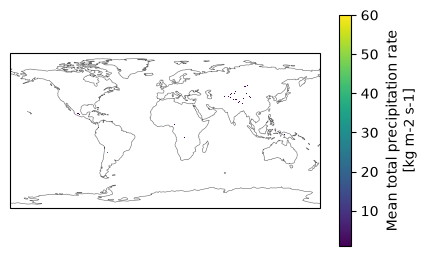

CESM2-WACCM_pr_g6_1p5k_003


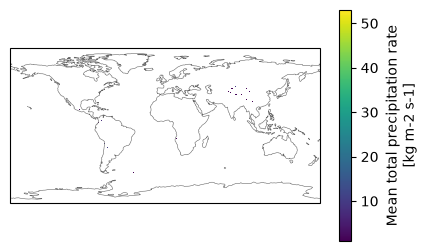

CESM2-WACCM_rsds_g6_1p5k_002


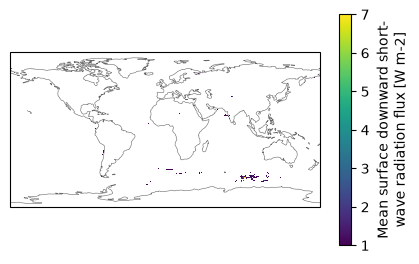

CESM2-WACCM_rsds_g6_1p5k_003


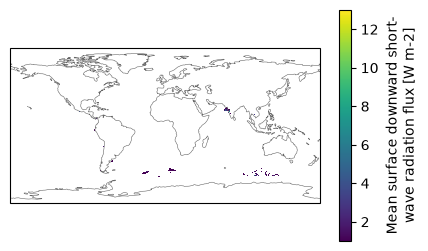

CESM2-WACCM_tas_g6_1p5k_002


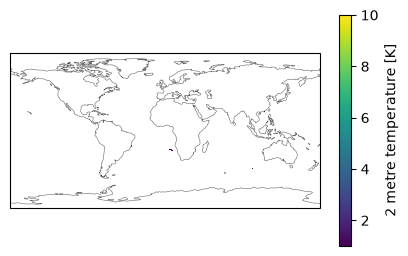

CESM2-WACCM_tas_g6_1p5k_003


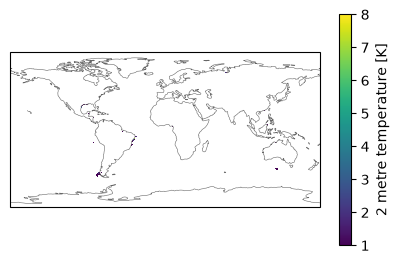

CESM2-WACCM_tasmax_g6_1p5k_002


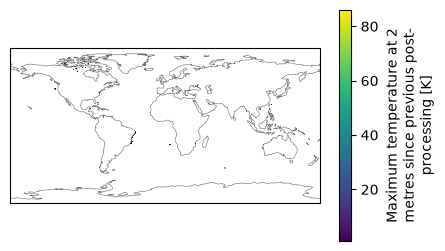

CESM2-WACCM_tasmax_g6_1p5k_003


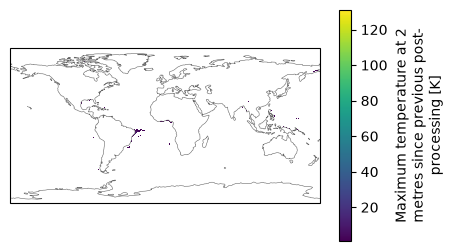

CESM2-WACCM_tasmin_g6_1p5k_002


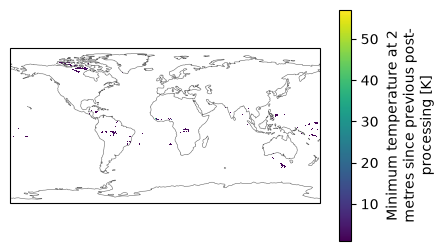

CESM2-WACCM_tasmin_g6_1p5k_003


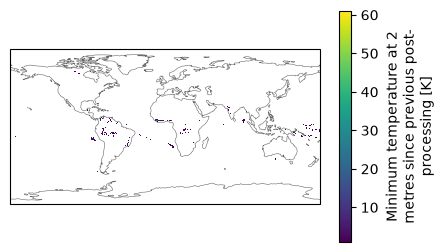

CESM2-WACCM_pr_historical_r2i1p1f1


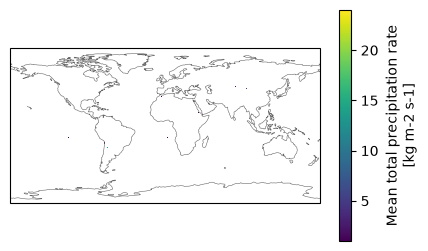

CESM2-WACCM_pr_historical_r3i1p1f1


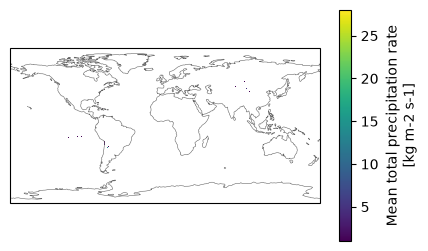

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmin_historical_001


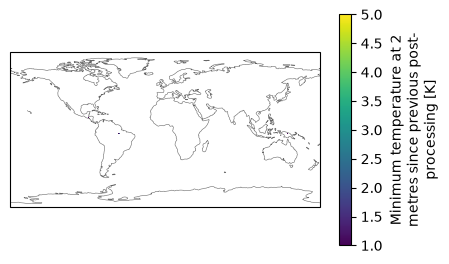

CESM2-WACCM_tasmin_g6_1p5k_end_002


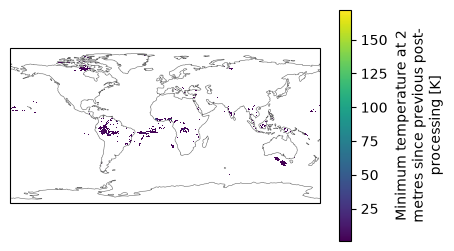

CESM2-WACCM_pr_g6_1p5k_end_002


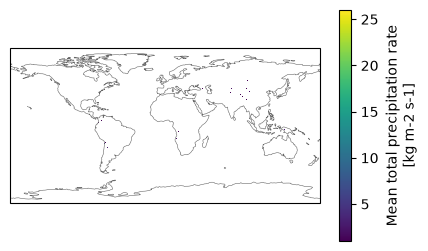

CESM2-WACCM_rsds_g6_1p5k_end_002


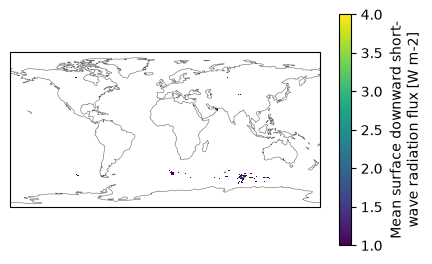

CESM2-WACCM_tas_g6_1p5k_end_002


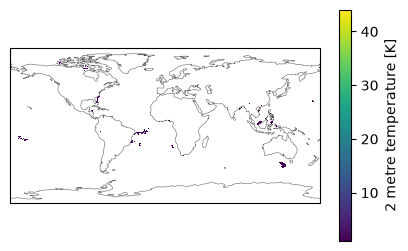

CESM2-WACCM_tasmax_g6_1p5k_end_002


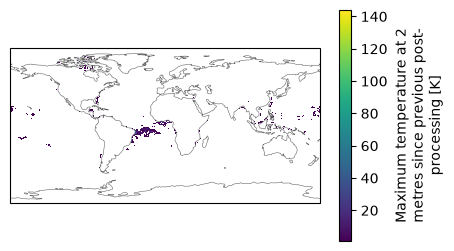

CESM2-WACCM_tasmax_ssp245_008


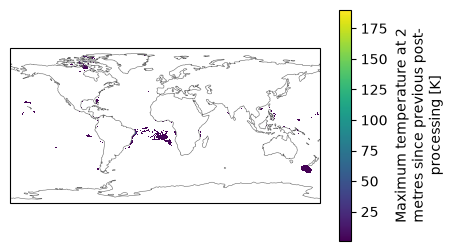

CESM2-WACCM_pr_ssp245_003


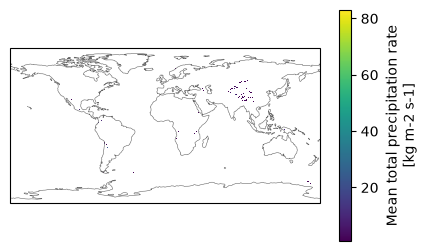

CESM2-WACCM_pr_ssp245_008


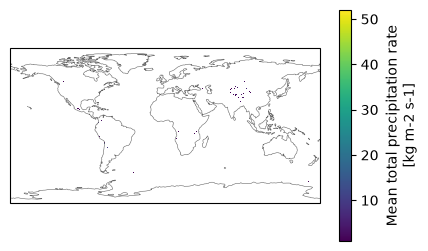

CESM2-WACCM_rsds_ssp245_003


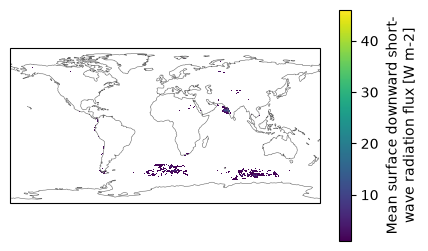

CESM2-WACCM_rsds_ssp245_008


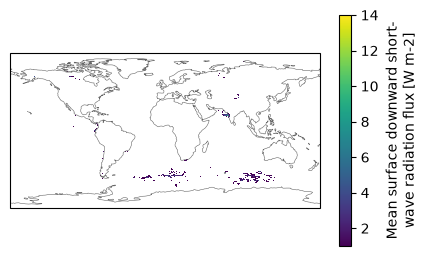

CESM2-WACCM_tas_ssp245_003


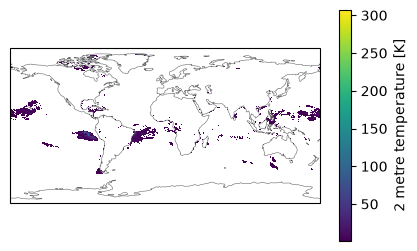

CESM2-WACCM_tas_ssp245_008


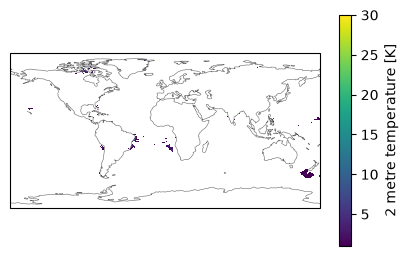

CESM2-WACCM_tasmin_ssp245_008


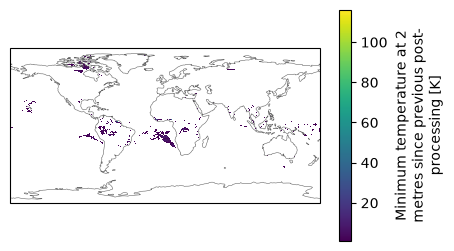

In [31]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="annual_outlier_flag",
    compute_flag=lambda da, var: flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual[var],
        outlier_thresh_high=outlier_thresh_high_annual[var],
        timescale="annual",
    ),
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
)

## 3. rsds-specific latitude check

In [22]:
def load_rsds_lims(
    key: str = "zonal_doy_max_rsds",
    fpath: str = DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr",
) -> xr.DataArray:
    return xr.open_zarr(fpath, group=key)["data"].load()

In [23]:
zonal_doy_max_rsds = load_rsds_lims()

31
CESM2-WACCM_rsds_g6_1p5k_002


/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


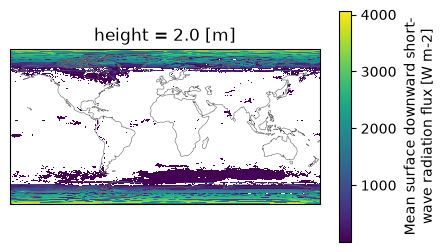

CESM2-WACCM_rsds_g6_1p5k_003


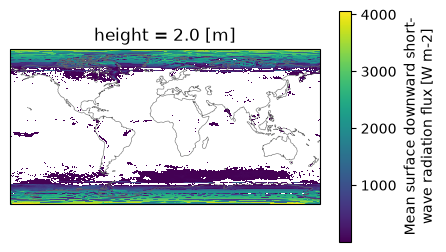

CESM2-WACCM_rsds_historical_r2i1p1f1


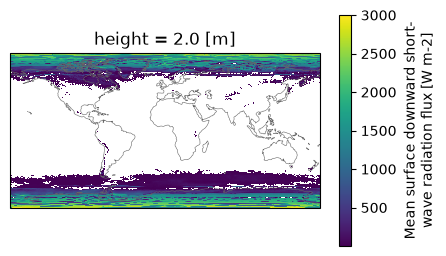

CESM2-WACCM_rsds_historical_r3i1p1f1


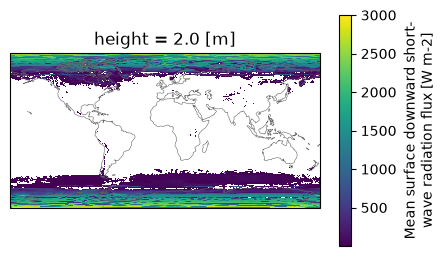

CESM2-WACCM_rsds_g6_1p5k_end_002


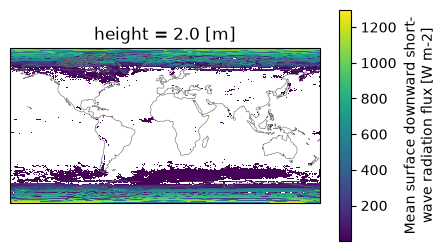

CESM2-WACCM_rsds_ssp245_003


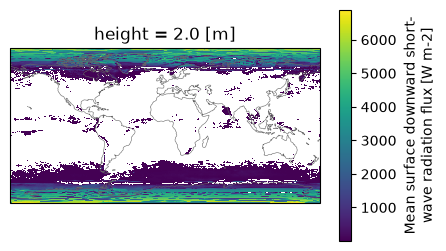

CESM2-WACCM_rsds_ssp245_008


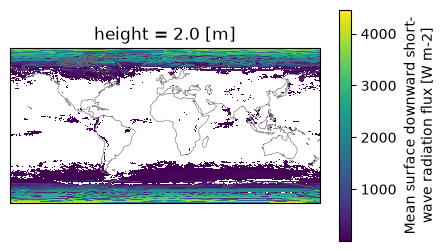

In [24]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="rsds_max_exceeded",
    compute_flag=lambda da, var: flag_rsds_above_max(da=da, zonal_doy_max_rsds=zonal_doy_max_rsds),
    var_filter="rsds",
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
)

## 4. temperature inconsistencies

In [25]:
from srm.qa_flags import flag_tasmax_tas_inconsistency, flag_tasmin_tas_inconsistency

31
CESM2-WACCM_tas_g6_1p5k_002


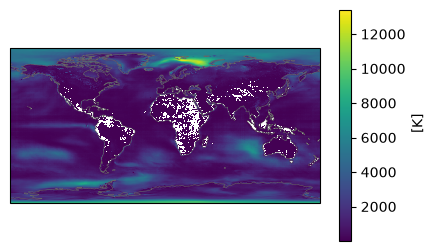

CESM2-WACCM_tas_g6_1p5k_003


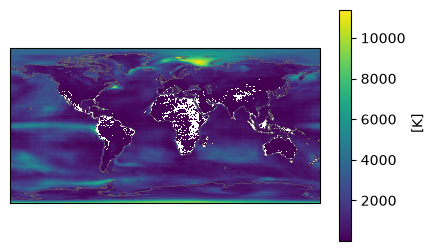

CESM2-WACCM_tas_g6_1p5k_end_002


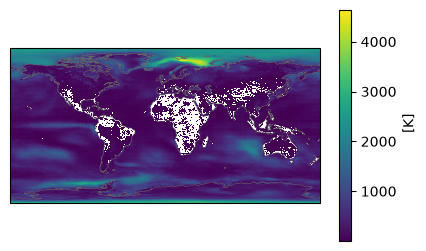

CESM2-WACCM_tas_ssp245_008


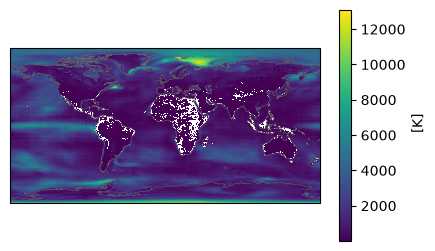

In [26]:
# This could be modified to fit within the run_flag_loop structure

var_filter = "tas"
plot = True

print(len(tags))
for tag in tags:
    gcm, var, scenario, ens = parse_tag(tag)
    if var_filter is not None and var != var_filter:
        continue

    tag_tasmin = f"{gcm}_tasmin_{scenario}_{ens}"
    tag_tasmax = f"{gcm}_tasmax_{scenario}_{ens}"
    if (tag_tasmin in tags) and (tag_tasmax in tags):
        print(tag)

        tas = get_data(tag=tag, trees=trees)
        tasmin = get_data(tag=tag_tasmin, trees=trees)
        tasmax = get_data(tag=tag_tasmax, trees=trees)

        flag_tas_tasmax = flag_tasmax_tas_inconsistency(tas, tasmax)
        flag_tas_tasmin = flag_tasmin_tas_inconsistency(tas, tasmin)

        flag_tas = (flag_tas_tasmax + flag_tas_tasmin) > 0
        flag_tasmin = flag_tas_tasmin
        flag_tasmax = flag_tas_tasmax

        write_individual_flags(
            flag_data=flag_tas,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tas",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        write_individual_flags(
            flag_data=flag_tasmax,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tasmax",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        write_individual_flags(
            flag_data=flag_tasmin,
            flag_name="temperature_inconsistency",
            gcm=gcm,
            var="tasmin",
            scenario=scenario,
            ens=ens,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        if plot:
            plot_flags(flags=flag_tas, time_varying=True, separate_low_high=False)
            plt.show()
            plt.close()

# C. Generate flags that are constant over time

In [12]:
from srm.qa_flags import (
    SCENARIO_COMPARISONS as scenario_comparisons,
    TREND_VARIABLE_SETTINGS as VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
)

g6_1p5k_ssp245
tas


/tmp/ipykernel_50615/1175807279.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

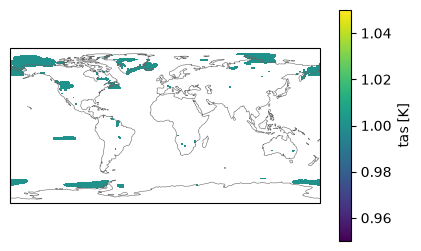

CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

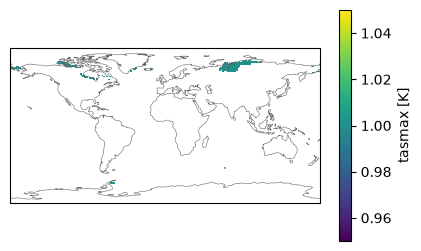

CESM2-WACCM_tasmax_ssp245_008
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

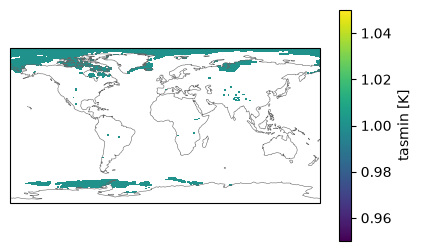

CESM2-WACCM_tasmin_ssp245_008
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
pr


/tmp/ipykernel_50615/1175807279.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

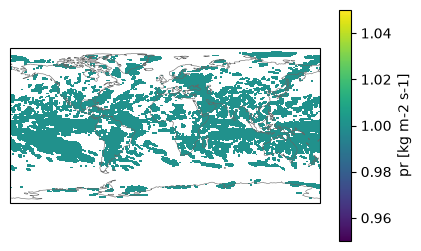

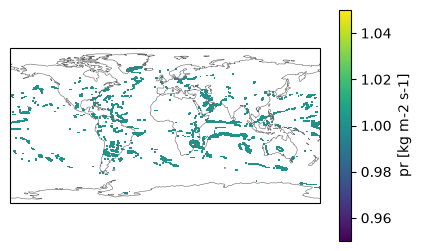

CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
rsds


/tmp/ipykernel_50615/1175807279.py:20: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

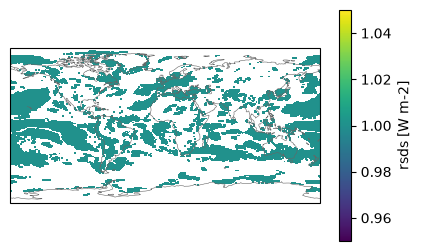

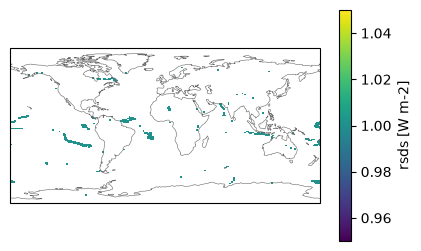

CESM2-WACCM_rsds_ssp245_003
CESM2-WACCM_rsds_ssp245_008
CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
ssp245_hist
tas


/tmp/ipykernel_50615/1175807279.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

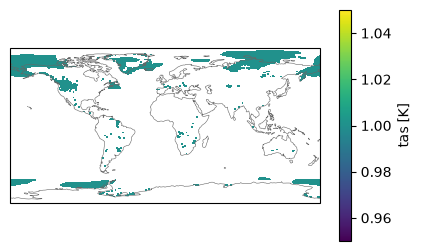

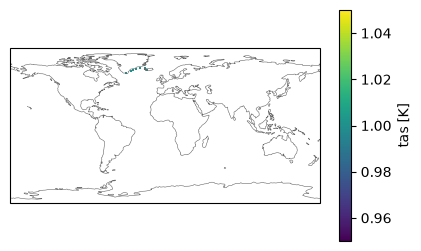

CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tas_ssp245_003
CESM2-WACCM_tas_ssp245_008
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

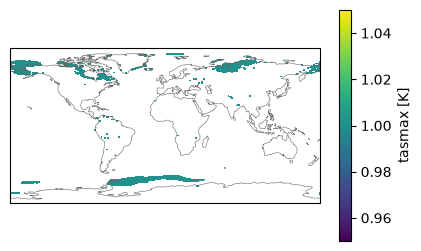

CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_ssp245_008
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

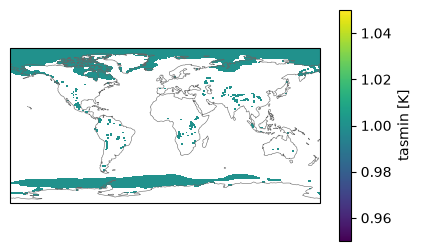

CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmin_ssp245_008
pr


/tmp/ipykernel_50615/1175807279.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

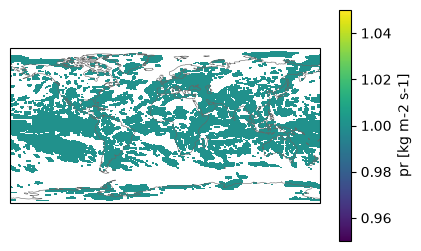

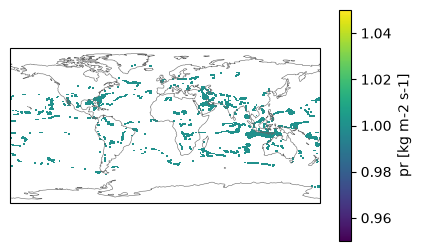

CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_pr_ssp245_003
CESM2-WACCM_pr_ssp245_008
rsds


/tmp/ipykernel_50615/1175807279.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 90
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env

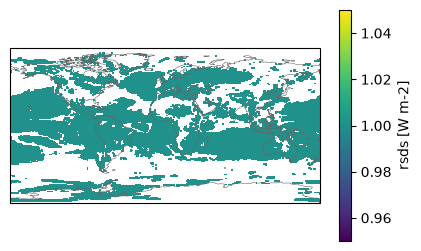

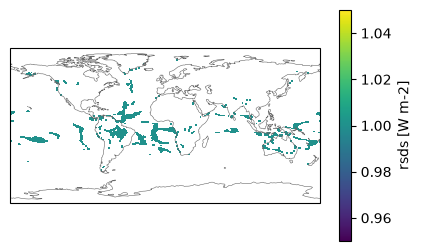

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_rsds_ssp245_003
CESM2-WACCM_rsds_ssp245_008
g6_1p5k_hist
tas


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

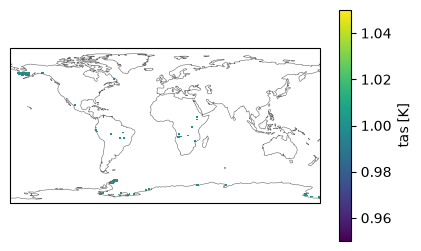

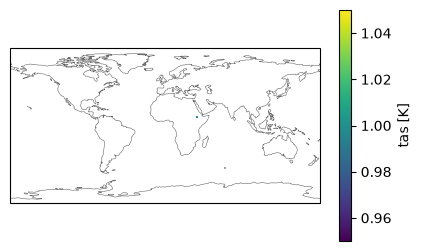

CESM2-WACCM_tas_historical_r2i1p1f1
CESM2-WACCM_tas_historical_r3i1p1f1
CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

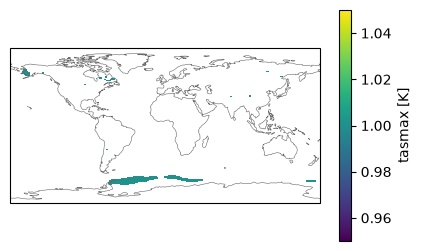

CESM2-WACCM_tasmax_historical_001
CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

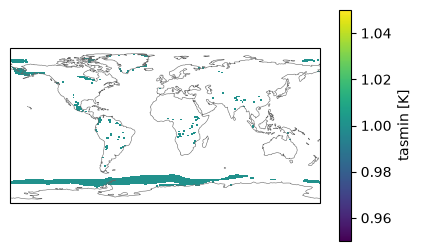

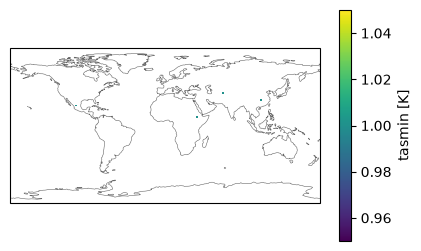

CESM2-WACCM_tasmin_historical_001
CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
pr


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

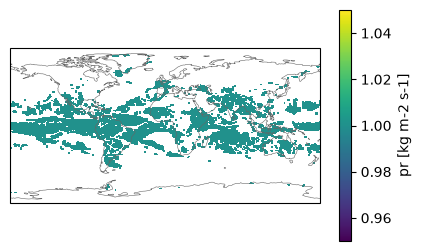

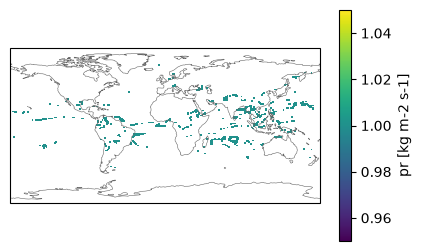

CESM2-WACCM_pr_historical_r2i1p1f1
CESM2-WACCM_pr_historical_r3i1p1f1
CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
rsds


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

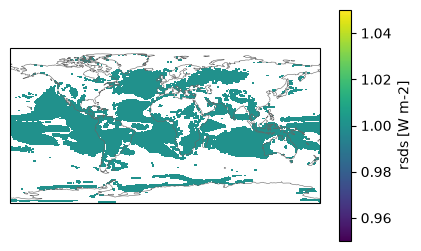

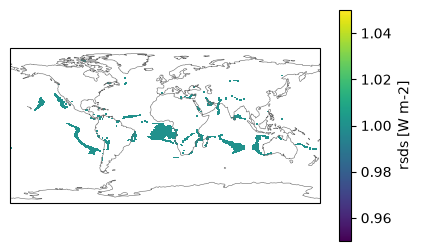

CESM2-WACCM_rsds_historical_r2i1p1f1
CESM2-WACCM_rsds_historical_r3i1p1f1
CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
g6_1p5k_end_g6_1p5k
tas


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

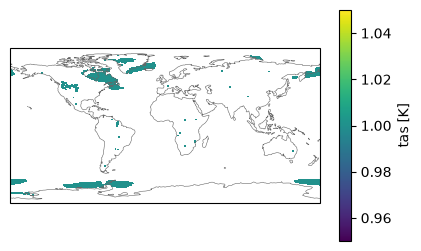

CESM2-WACCM_tas_g6_1p5k_002
CESM2-WACCM_tas_g6_1p5k_003
CESM2-WACCM_tas_g6_1p5k_end_002
tasmax


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

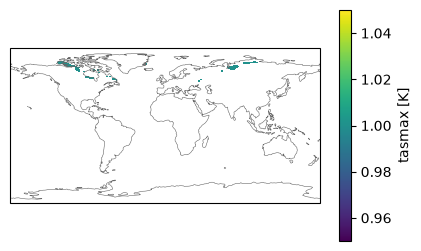

CESM2-WACCM_tasmax_g6_1p5k_002
CESM2-WACCM_tasmax_g6_1p5k_003
CESM2-WACCM_tasmax_g6_1p5k_end_002
tasmin


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

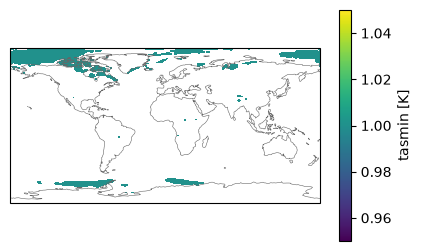

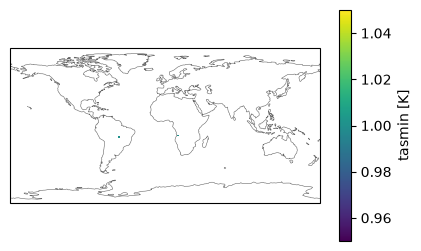

CESM2-WACCM_tasmin_g6_1p5k_002
CESM2-WACCM_tasmin_g6_1p5k_003
CESM2-WACCM_tasmin_g6_1p5k_end_002
pr


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

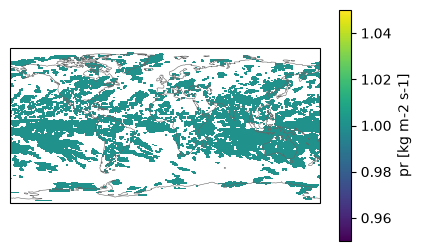

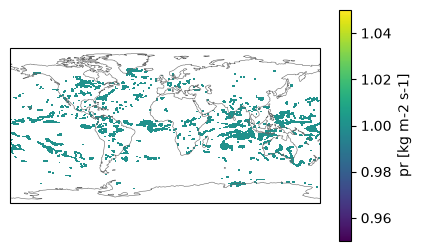

CESM2-WACCM_pr_g6_1p5k_002
CESM2-WACCM_pr_g6_1p5k_003
CESM2-WACCM_pr_g6_1p5k_end_002
rsds


/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 24
  intermediate = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/routines.py:331: PerformanceWarning: Increasing number of chunks by factor of 18
  intermediate = blockwise(
/opt/coile

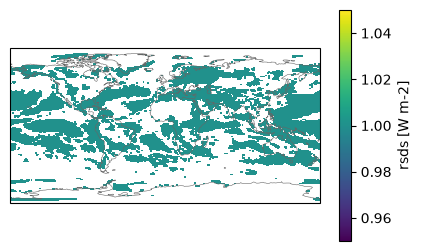

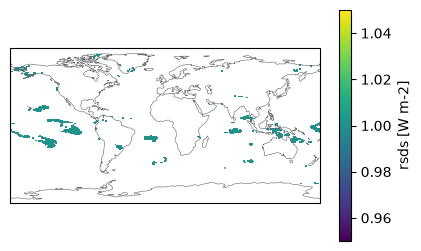

CESM2-WACCM_rsds_g6_1p5k_002
CESM2-WACCM_rsds_g6_1p5k_003
CESM2-WACCM_rsds_g6_1p5k_end_002


In [35]:
plot = True
for key in scenario_comparisons:
    print(key)
    comparison_dict = scenario_comparisons[key]
    scenario1 = comparison_dict["scenario1"]
    scenario2 = comparison_dict["scenario2"]
    scenario1_time_slice = comparison_dict["scenario1_time_slice"]
    scenario2_time_slice = comparison_dict["scenario2_time_slice"]

    for gcm in GCMS:
        for var in VARIABLES:
            print(var)
            # Find tags to use in scenario comparison (all ensemble members for this variable and gcm for the two comparison scenarios)
            tags_scenario1 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario1) * (variables_np == var)
            ]
            tags_scenario2 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario2) * (variables_np == var)
            ]

            # Calculate distortions
            [delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds] = (
                calculate_ensemble_mean_deltas(
                    variable=var,
                    tags_scenario1=tags_scenario1,
                    tags_scenario2=tags_scenario2,
                    gcm=gcm,
                    scenario1=scenario1,
                    scenario2=scenario2,
                    scenario1_time_slice=scenario1_time_slice,
                    scenario2_time_slice=scenario2_time_slice,
                    trees=trees,
                )
            )

            distortion_absolute = delta_ds_coarse - delta_raw
            distortion_pct = delta_ds_coarse_pct - delta_raw_pct

            # Flag distortions at coarse scale
            abs_tol = VARIABLE_SETTINGS[var]["abs_tol"]
            pct_tol = VARIABLE_SETTINGS[var]["pct_tol"]
            sign_flip_tol = VARIABLE_SETTINGS[var]["sign_flip"]
            scale = VARIABLE_SETTINGS[var]["scale"]

            trend_distortion_flag = calculate_distortion_flags(
                distortion_absolute=distortion_absolute * scale,
                distortion_pct=distortion_pct,
                tolerance_absolute=abs_tol,
                tolerance_pct=pct_tol,
            )

            flipped_sign_flag = sign_flip_mask(
                delta_ds_coarse * scale, delta_raw * scale, threshold=sign_flip_tol
            )

            # Propagate coarse distortion flags to fine scale
            trend_distortion_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
            )
            trend_distortion_flag_fine = trend_distortion_flag_fine_frac > 0

            flipped_sign_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
            )
            flipped_sign_flag_fine = flipped_sign_flag_fine_frac > 0

            if plot:
                plot_flags(
                    flags=trend_distortion_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

                plot_flags(
                    flags=flipped_sign_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

            # Write out flags
            tags_to_flag = np.concat([tags_scenario1, tags_scenario2])
            for tag in tags_to_flag:
                print(tag)
                gcm, var, scenario, ens = parse_tag(tag)
                write_individual_flags(
                    flag_data=trend_distortion_flag_fine,
                    flag_name="trend_distortion_" + scenario1 + "_" + scenario2,
                    gcm=gcm,
                    var=var,
                    scenario=scenario,
                    ens=ens,
                    write_mode="a",
                    bucket=BUCKET,
                    prefix=PREFIX,
                    time_varying=False,
                )

                write_individual_flags(
                    flag_data=flipped_sign_flag_fine,
                    flag_name="flipped_sign" + scenario1 + "_" + scenario2,
                    gcm=gcm,
                    var=var,
                    scenario=scenario,
                    ens=ens,
                    write_mode="a",
                    bucket=BUCKET,
                    prefix=PREFIX,
                    time_varying=False,
                )

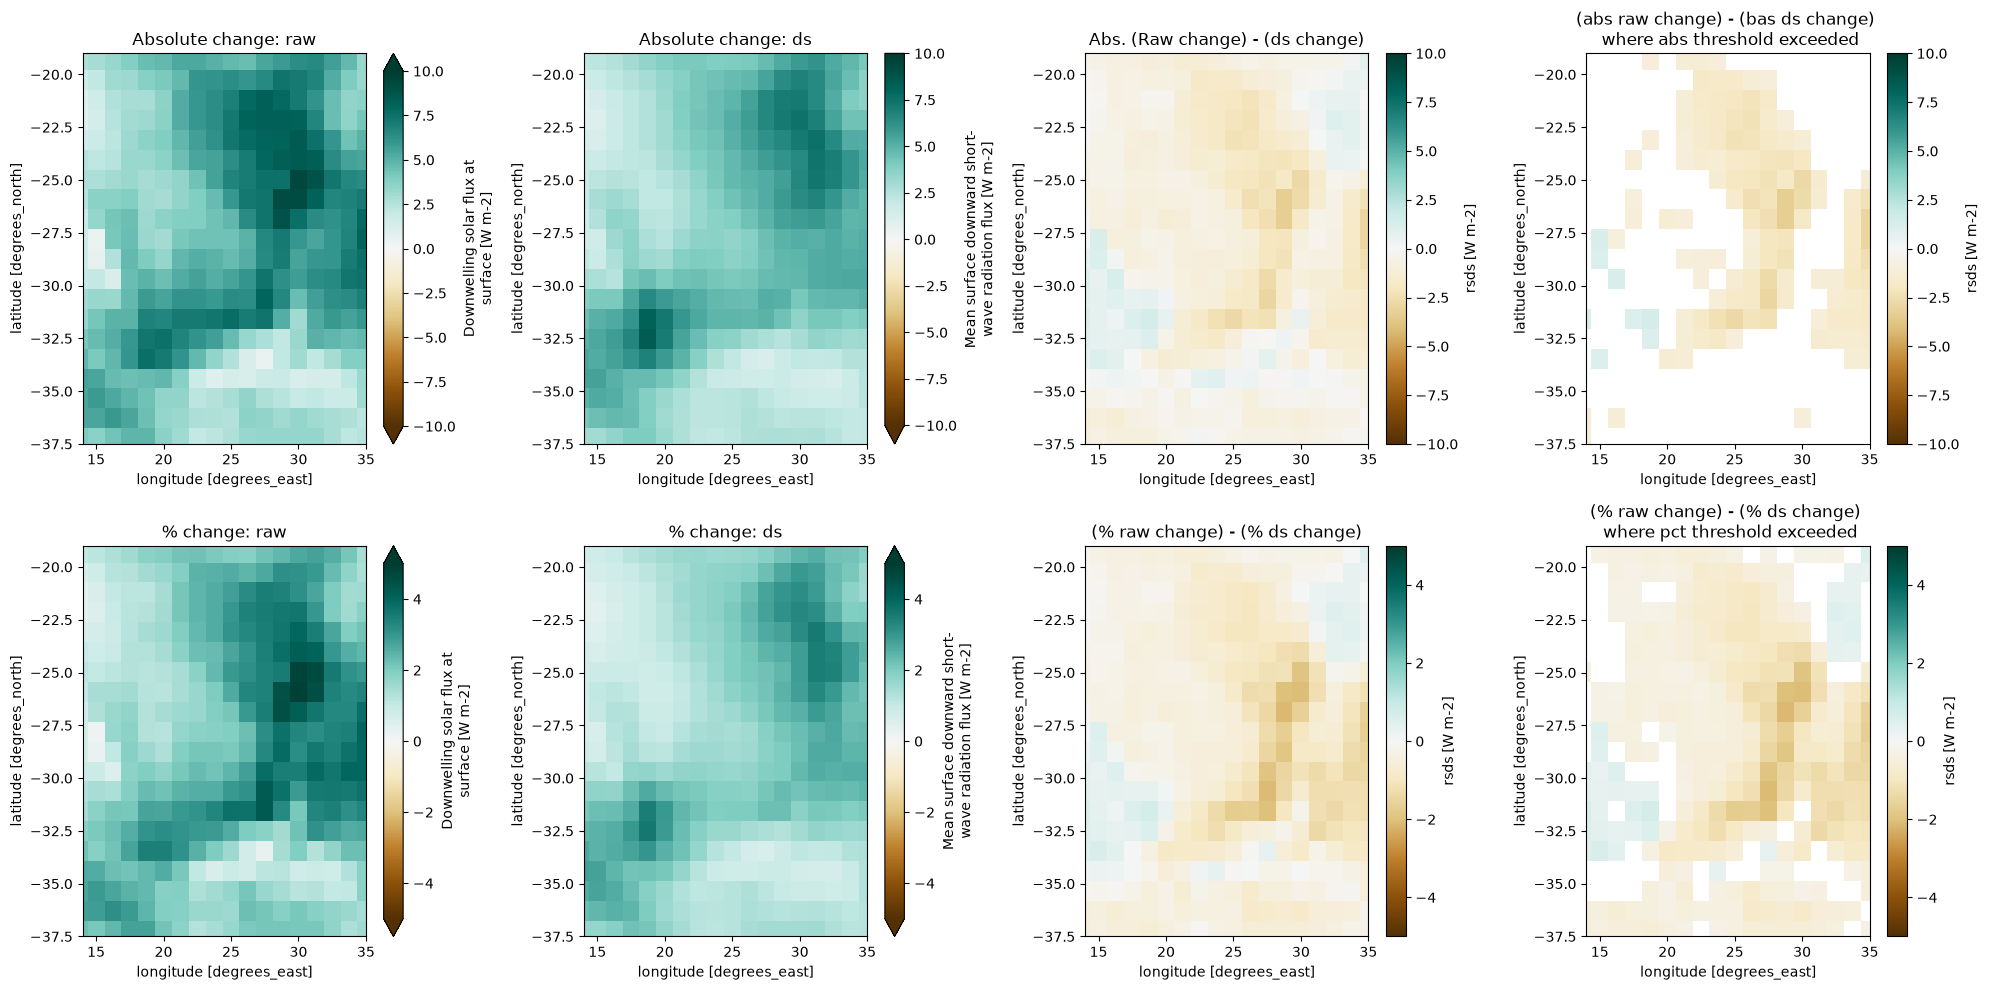

In [36]:
cmap = plt.cm.PuOr
vmax_abs = 5 / scale
vmin_abs = -5 / scale
vmin_pct = -5
vmax_pct = 5

cmap = plt.cm.BrBG
vmax_abs = 10 / scale
vmin_abs = -10 / scale
vmin_pct = -5
vmax_pct = 5


def format_subplot():
    plt.xlim([14, 35])
    plt.ylim([-37.5, -19])


plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
delta_raw.plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Absolute change: raw")
plt.subplot(2, 4, 2)
delta_ds_coarse.plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Absolute change: ds")
plt.subplot(2, 4, 3)
(delta_ds_coarse - delta_raw).plot(vmin=vmin_abs, vmax=vmax_abs, cmap=cmap)
format_subplot()
plt.title("Abs. (Raw change) - (ds change)")
plt.subplot(2, 4, 4)
delta_delta = delta_ds_coarse - delta_raw
(delta_delta).where(np.abs(delta_delta) > abs_tol / scale).plot(
    vmin=vmin_abs, vmax=vmax_abs, cmap=cmap
)
plt.title("(abs raw change) - (bas ds change) \n where abs threshold exceeded")
format_subplot()

plt.subplot(2, 4, 5)
delta_raw_pct.plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("% change: raw")
format_subplot()
plt.subplot(2, 4, 6)
delta_ds_coarse_pct.plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("% change: ds")
format_subplot()
plt.subplot(2, 4, 7)
(delta_ds_coarse_pct - delta_raw_pct).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("(% raw change) - (% ds change)")
format_subplot()
plt.subplot(2, 4, 8)
delta_delta = delta_ds_coarse_pct - delta_raw_pct
(delta_delta).where(np.abs(delta_delta) > pct_tol).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.title("(% raw change) - (% ds change) \n where pct threshold exceeded")
format_subplot()
plt.tight_layout()

(-37.5, -19.0)

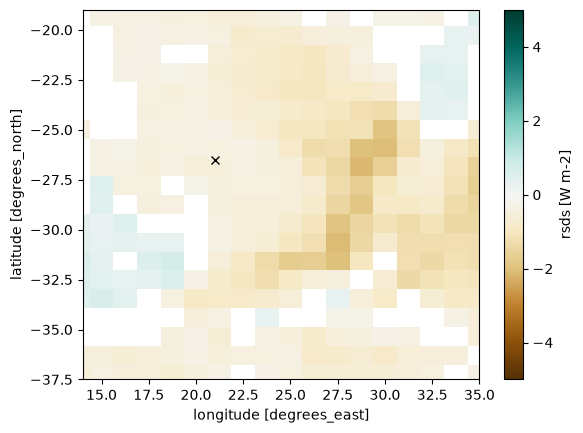

In [37]:
(delta_delta).where(np.abs(delta_delta) > pct_tol).plot(vmin=vmin_pct, vmax=vmax_pct, cmap=cmap)
plt.plot([21], [-26.5], "xk")
plt.xlim([14, 35])
plt.ylim([-37.5, -19])

In [38]:
# Construct data arrays including all relevant ensemble members
das_scenario1 = []
ens_scenario1 = []
for tag in tags_scenario1:
    da = get_data(tag=tag, trees=trees)
    thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
    das_scenario1.append(da)
    ens_scenario1.append(thisens)

var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))

das_scenario2 = []
ens_scenario2 = []
for tag in tags_scenario2:
    da = get_data(tag=tag, trees=trees)
    thisgcm, thisvar, thisscenario, thisens = parse_tag(tag)
    das_scenario2.append(da)
    ens_scenario2.append(thisens)

var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))

In [39]:
# Take ensemble mean across comparison time periods in raw data
raw_ds = catalog.get(gcm).to_xarray()
raw_scenario1 = raw_ds[scenario1][var]
raw_scenario2 = raw_ds[scenario2][var]

ilat = -26.5
ilon = 21
raw_scenario1_pt = (
    raw_scenario1.sel(lat=ilat, lon=ilon, method="nearest").groupby("time.year").mean().load()
)
raw_scenario2_pt = (
    raw_scenario2.sel(lat=ilat, lon=ilon, method="nearest").groupby("time.year").mean().load()
)

In [40]:
if cluster is not None:
    cluster.shutdown()
else:
    print("no cluster was created (cached run); nothing to shut down")

# D. Read in flags

In [41]:
from srm.qa_flags import get_intermediate_flags

gcm = "CESM2-WACCM"
var = "rsds"
scenario = "ssp245"
ens = "008"

tag = f"{gcm}_{var}_{scenario}_{ens}"
flag_ds = get_intermediate_flags(tag=tag, bucket=BUCKET, prefix=PREFIX)

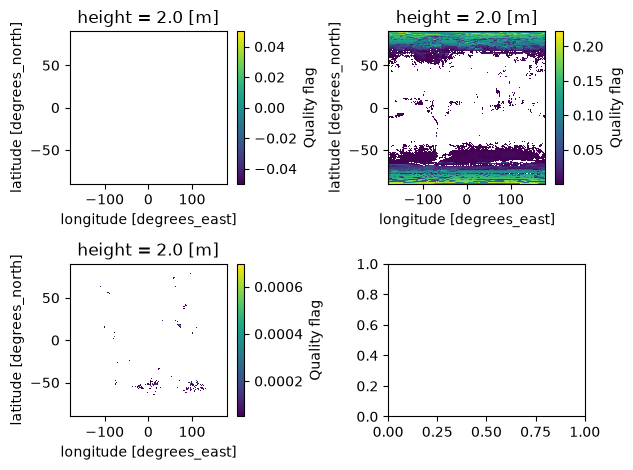

In [42]:
fig, axes = plt.subplots(nrows=2, ncols=2)
flag_frac = flag_ds["outside_global_plausible_range"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 0])
flag_frac = flag_ds["rsds_max_exceeded"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 1])
flag_frac = flag_ds["annual_outlier_flag"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[1, 0])
plt.tight_layout()

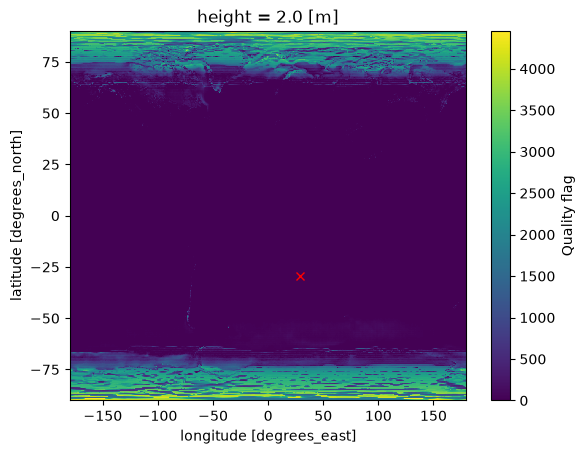

In [43]:
flag_ds["rsds_max_exceeded"].sum(dim="time").plot()
plt.plot([28.5], [-29.6], "xr")

In [44]:
comparison_ds = trees[gcm][scenario][var][ens]
da = comparison_ds[var]

In [45]:
da_raw = catalog.get(gcm).to_xarray()[scenario][var].sel(ensemble_member=ens)

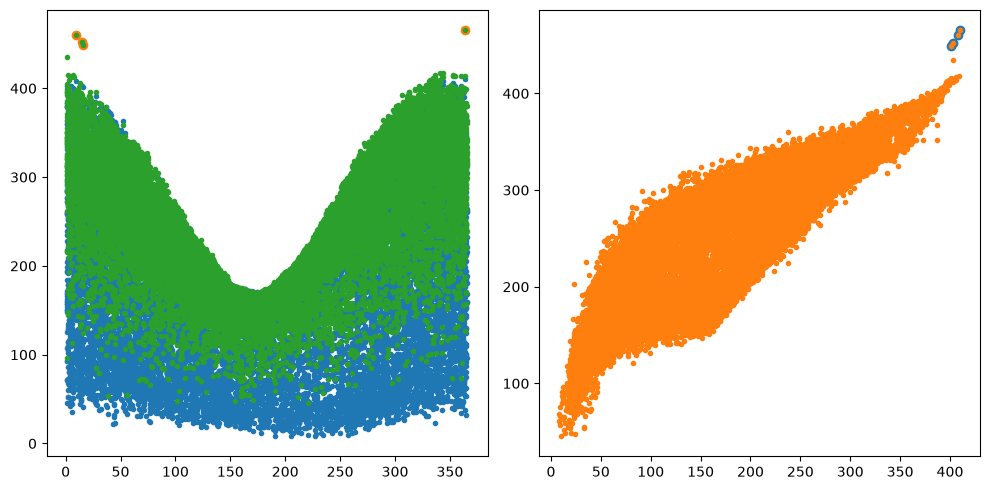

In [46]:
ilat = -29.6
ilon = 28.5
pt_flagged = flag_ds["rsds_max_exceeded"].sel(lat=ilat, lon=ilon, method="nearest")
pt_da = da.sel(lat=ilat, lon=ilon, method="nearest")
pt_da_raw = da_raw.sel(lat=ilat, lon=ilon, method="nearest")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(da_raw["time.dayofyear"], pt_da_raw, ".")
plt.plot(da["time.dayofyear"], pt_da.where(pt_flagged), "o")
plt.plot(da["time.dayofyear"], pt_da, ".")

plt.subplot(1, 2, 2)
plt.plot(pt_da_raw[0 : len(pt_da)], pt_da.where(pt_flagged), "o")
plt.plot(pt_da_raw[0 : len(pt_da)], pt_da, ".")
plt.tight_layout()